In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns
import numpy as np

# 日本語フォントの設定（環境に合わせて設定してください）
plt.rcParams["font.family"] = "Yu Gothic"   # Windows
#plt.rcParams['font.family'] = 'sans-serif' # Windowsなど
# plt.rcParams['font.family'] = 'AppleGothic' # Macの場合

# 1. データの読み込み
# 実際のファイル名やパスに合わせて変更してください
df = pd.read_csv('./Database/Benesse/1571.csv', encoding='utf-8-sig')
# ここではダミーとしてdfが読み込まれていると仮定します

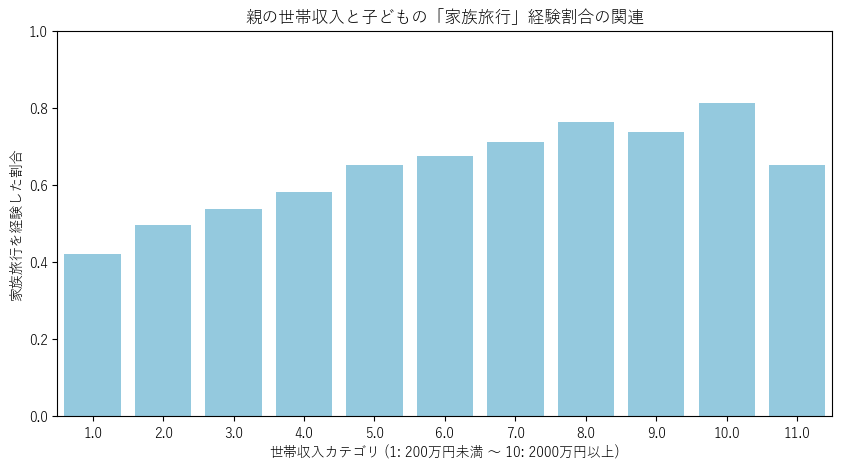

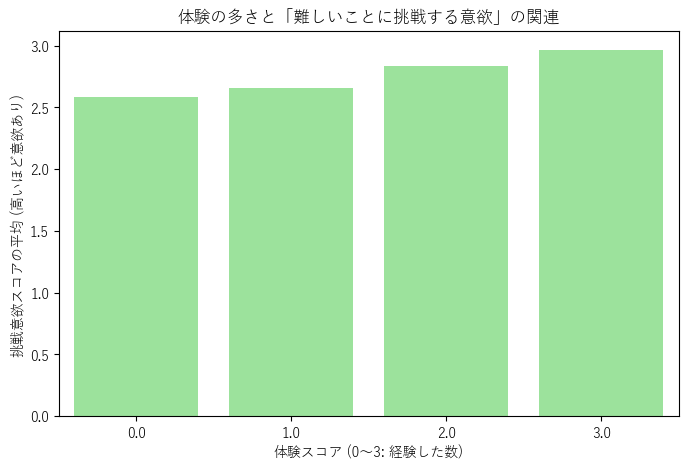

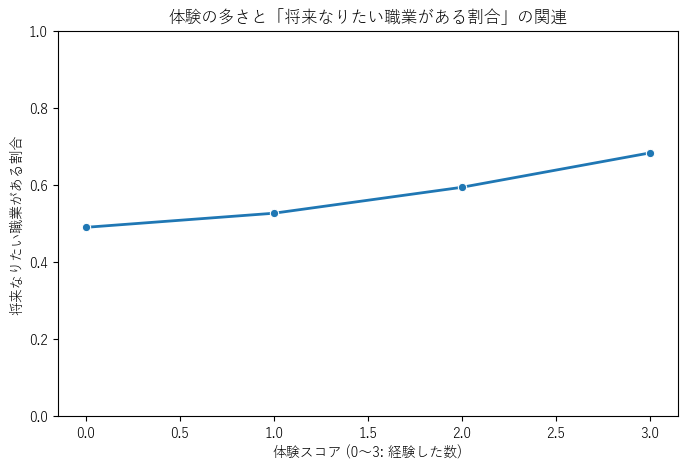

In [7]:
# 2. 分析に必要な変数の抽出（Wave1の例）
columns_to_use = [
    'ds0000000052_w1p', # 昨年の世帯収入（親）: 1(200万未満)〜10(2000万以上)
    'ds0000000268_w1c', # 経験：家族で旅行をする（子）: 0(非選択), 1(選択)
    'ds0000000270_w1c', # 経験：自然の中で思いっきり遊ぶ（子）: 0(非選択), 1(選択)
    'ds0000000271_w1c', # 経験：美術館や博物館に行く（子）: 0(非選択), 1(選択)
    'ds0000000363_w1c', # 性格・特性：難しいことや新しいことにいつも挑戦したい（子）: 1(とても)〜4(まったく)
    'ds0000000210_w1c'  # 将来なりたい職業はあるか（子）: 1(ある), 2(ない)
]

# 分析用データフレームの作成
df_subset = df[columns_to_use].copy()

# 3. 欠損値の処理
# 7777(質問なし), 8888(非該当), 9999(無回答・不明) をNaN(欠損値)に置き換えて除外する[5]
for col in columns_to_use:
    df_subset[col] = df_subset[col].replace(7777, np.nan)
    df_subset[col] = df_subset[col].replace(8888, np.nan)
    df_subset[col] = df_subset[col].replace(9999, np.nan)

df_subset = df_subset.dropna()

# ---------------------------------------------------------
# 分析①：世帯収入によって「体験」の機会に差があるか？
# ---------------------------------------------------------
# 世帯収入カテゴリごとに、家族旅行の経験(1)の平均（割合）を算出
income_travel = df_subset.groupby('ds0000000052_w1p')['ds0000000268_w1c'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='ds0000000052_w1p', y='ds0000000268_w1c', data=income_travel, color='skyblue')
plt.title('親の世帯収入と子どもの「家族旅行」経験割合の関連')
plt.xlabel('世帯収入カテゴリ (1: 200万円未満 ～ 10: 2000万円以上)')
plt.ylabel('家族旅行を経験した割合')
plt.ylim(0, 1)
plt.show()

# ---------------------------------------------------------
# 分析②：多様な「体験」は子どもの意欲や将来の夢に影響するか？
# ---------------------------------------------------------
# 3つの体験の合計スコアを作成 (0～3点)
df_subset['experience_score'] = df_subset['ds0000000268_w1c'] + \
                                df_subset['ds0000000270_w1c'] + \
                                df_subset['ds0000000271_w1c']

# 挑戦意欲スコアの調整
# 元のデータは「1:とてもあてはまる ～ 4:まったくあてはまらない」なので、
# 数値が大きいほど意欲が高いように反転させる（5 - 現在の値）
df_subset['challenge_spirit'] = 5 - df_subset['ds0000000363_w1c']

# 体験スコア別の「挑戦意欲」の平均を算出
exp_challenge = df_subset.groupby('experience_score')['challenge_spirit'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='experience_score', y='challenge_spirit', data=exp_challenge, color='lightgreen')
plt.title('体験の多さと「難しいことに挑戦する意欲」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('挑戦意欲スコアの平均 (高いほど意欲あり)')
plt.show()

# 将来なりたい職業のダミー変数化 (1:ある->1, 2:ない->0)
df_subset['has_dream'] = df_subset['ds0000000210_w1c'].apply(lambda x: 1 if x == 1 else 0)

# 体験スコア別の「将来なりたい職業がある割合」を算出
exp_dream = df_subset.groupby('experience_score')['has_dream'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='experience_score', y='has_dream', data=exp_dream, marker='o', linewidth=2)
plt.title('体験の多さと「将来なりたい職業がある割合」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('将来なりたい職業がある割合')
plt.ylim(0, 1)
plt.show()

In [12]:
from IPython.display import display

print("■ 分析①：親の世帯収入カテゴリごとの「家族旅行」経験割合")
# 1: 200万円未満 ～ 10: 2000万円以上
display(income_travel)

print("■ 分析②：体験スコア(0〜3)別の「挑戦意欲」の平均")
# スコアが高いほど意欲が高い
display(exp_challenge)

print("■ 分析②：体験スコア(0〜3)別の「将来なりたい職業がある割合」")
display(exp_dream)

■ 分析①：親の世帯収入カテゴリごとの「家族旅行」経験割合


,ds0000000052_w1p,ds0000000268_w1c
0,1.0,0.421725
1,2.0,0.496350
2,3.0,0.539515
3,4.0,0.583401
4,5.0,0.651246
5,6.0,0.676355
6,7.0,0.712811
7,8.0,0.764706
8,9.0,0.738372
9,10.0,0.814433


■ 分析②：体験スコア(0〜3)別の「挑戦意欲」の平均


,experience_score,challenge_spirit
0,0.0,2.580374
1,1.0,2.660070
2,2.0,2.836358
3,3.0,2.967923


■ 分析②：体験スコア(0〜3)別の「将来なりたい職業がある割合」


,experience_score,has_dream
0,0.0,0.490645
1,1.0,0.527243
2,2.0,0.594555
3,3.0,0.683737


C:\Users\81808\AppData\Local\Temp\ipykernel_21308\2687829739.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='own_device', y='research_skill', data=df_idea2, palette='Set2')


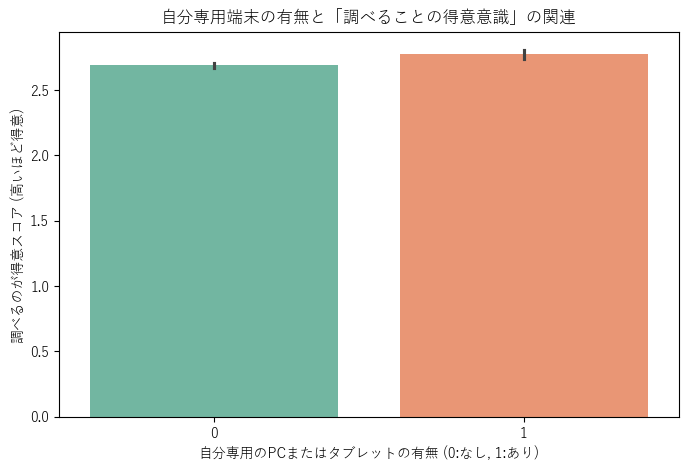

C:\Users\81808\AppData\Local\Temp\ipykernel_21308\2687829739.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ds0000000820_w6c', y='study_hard_score', data=df_idea2, palette='Set3')


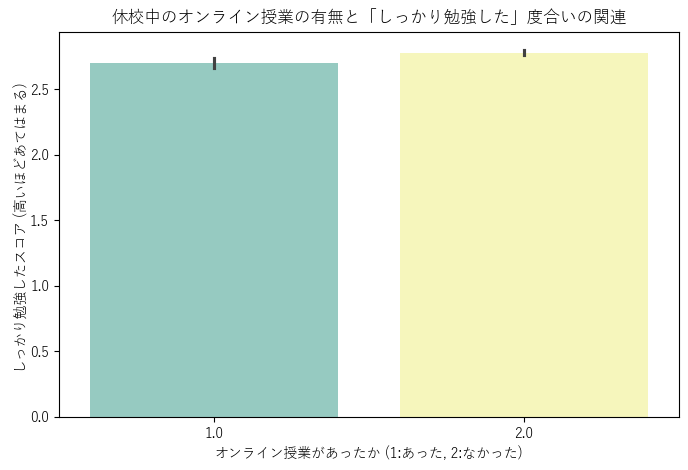

In [ ]:
# =========================================================
# アイデア案2：デジタル環境へのアクセス格差と「自分で調べる力」の差
# =========================================================

# 分析に必要な変数の抽出（Wave 6のデータを使用）
columns_idea2 = [
    'ds0000000524_w6c', # メディア利用：パソコン (1:使っていない, 2:家族と共有, 3:自分専用)
    'ds0000000525_w6c', # メディア利用：タブレット (1:使っていない, 2:家族と共有, 3:自分専用)
    'ds0000000330_w6c', # 得意・苦手：わからないことや知らないことを調べること (1:とても得意〜4:とても苦手)
    'ds0000000820_w6c', # コロナ禍休校中の学校対応：オンラインで授業があった (1:あった, 2:なかった)
    'ds0000000799_w6c'  # コロナ禍休校中の家庭生活：しっかり勉強した (1:とてもあてはまる〜4:まったくあてはまらない)
]

df_idea2 = df[columns_idea2].copy()

# 欠損値の処理 (7777, 8888, 9999 を NaN に置換して除外)
for col in columns_idea2:
    df_idea2[col] = df_idea2[col].replace(7777, np.nan)
    df_idea2[col] = df_idea2[col].replace(8888, np.nan)
    df_idea2[col] = df_idea2[col].replace(9999, np.nan)
df_idea2 = df_idea2.dropna()

# 自分専用のPCまたはタブレットがあるかどうかのフラグを作成
# パソコンまたはタブレットが「3(自分専用のものを使っている)」なら1、そうでないなら0
df_idea2['own_device'] = ((df_idea2['ds0000000524_w6c'] == 3) | (df_idea2['ds0000000525_w6c'] == 3)).astype(int)

# 「調べること」の得意スコアの調整（大きいほど得意になるよう反転：5 - 現在の値）
df_idea2['research_skill'] = 5 - df_idea2['ds0000000330_w6c']

# 休校中に「しっかり勉強した」かのスコア（大きいほどあてはまるよう反転：5 - 現在の値）
df_idea2['study_hard_score'] = 5 - df_idea2['ds0000000799_w6c']

# グラフ①：自分専用端末の有無と「調べる力」の関連
plt.figure(figsize=(8, 5))
sns.barplot(x='own_device', y='research_skill', data=df_idea2, palette='Set2')
plt.title('自分専用端末の有無と「調べることの得意意識」の関連')
plt.xlabel('自分専用のPCまたはタブレットの有無 (0:なし, 1:あり)')
plt.ylabel('調べるのが得意スコア (高いほど得意)')
plt.show()

# グラフ②：オンライン授業の有無と休校中の学習状況の関連
plt.figure(figsize=(8, 5))
sns.barplot(x='ds0000000820_w6c', y='study_hard_score', data=df_idea2, palette='Set3')
plt.title('休校中のオンライン授業の有無と「しっかり勉強した」度合いの関連')
plt.xlabel('オンライン授業があったか (1:あった, 2:なかった)')
plt.ylabel('しっかり勉強したスコア (高いほどあてはまる)')
plt.show()

In [13]:
print("■ グラフ①：自分専用端末の有無(0:なし, 1:あり)ごとの「調べることの得意意識」平均")
device_skill_mean = df_idea2.groupby('own_device')['research_skill'].mean().reset_index()
device_skill_mean.columns = ['自分専用端末の有無', '調べるのが得意スコア平均']
display(device_skill_mean)

print("■ グラフ②：休校中のオンライン授業の有無(1:あった, 2:なかった)ごとの「しっかり勉強した」度合い平均")
online_study_mean = df_idea2.groupby('ds0000000820_w6c')['study_hard_score'].mean().reset_index()
online_study_mean.columns = ['オンライン授業の有無', 'しっかり勉強したスコア平均']
display(online_study_mean)

■ グラフ①：自分専用端末の有無(0:なし, 1:あり)ごとの「調べることの得意意識」平均


,自分専用端末の有無,調べるのが得意スコア平均
0,0,2.690397
1,1,2.772566


■ グラフ②：休校中のオンライン授業の有無(1:あった, 2:なかった)ごとの「しっかり勉強した」度合い平均


,オンライン授業の有無,しっかり勉強したスコア平均
0,1.0,2.697647
1,2.0,2.776706


[6. 2. 5. 7. 4. 3. 1.]


C:\Users\81808\AppData\Local\Temp\ipykernel_21308\4021846188.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='child_gender_label', y='math_liking_child', data=df_idea3, palette='pastel')


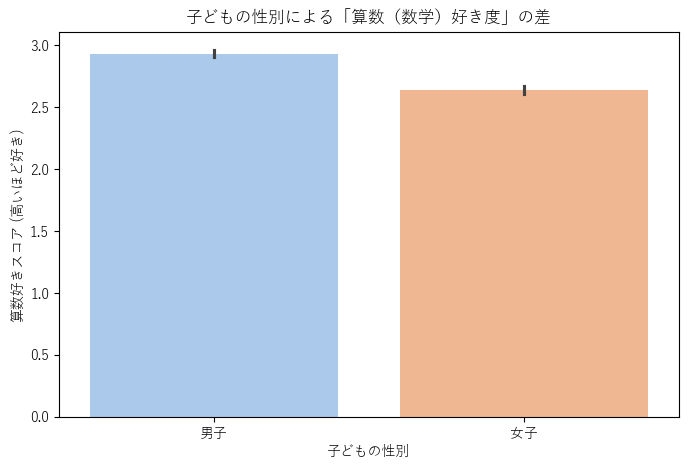

C:\Users\81808\AppData\Local\Temp\ipykernel_21308\4021846188.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bias_level', y='math_liking_child', data=df_idea3_girls, palette='Set1')


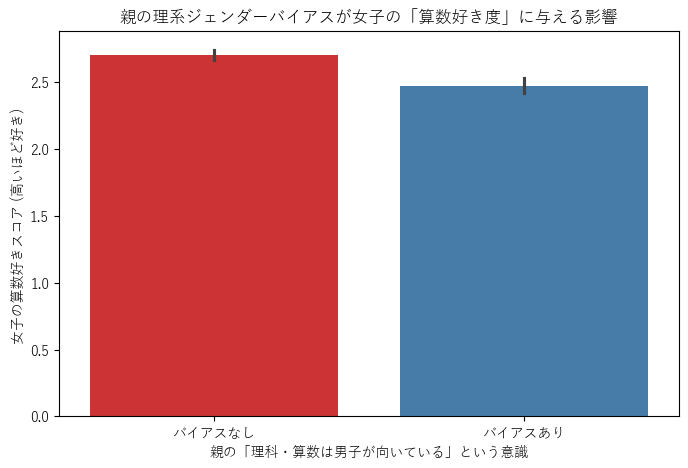

C:\Users\81808\AppData\Local\Temp\ipykernel_21308\4021846188.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bias_level', y='aim_univ', data=df_idea3_girls, palette='Set1')


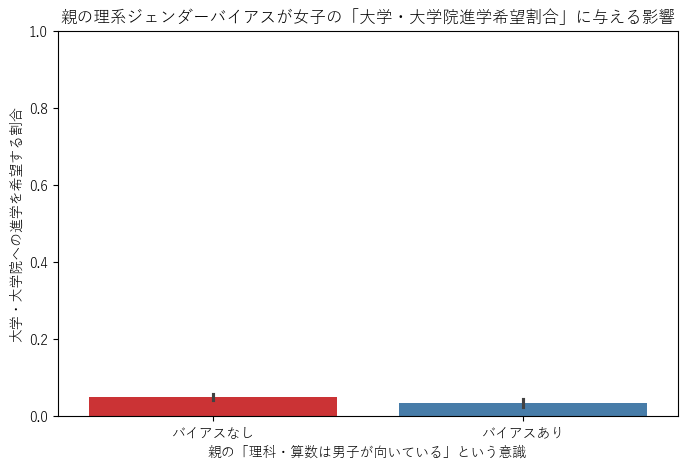

In [ ]:
# =========================================================
# アイデア案3：「無意識のバイアス」による進路選択の格差（見えない壁）
# =========================================================

# 分析に必要な変数の抽出（Wave 6のデータを使用）
columns_idea3 = [
    'ds0000000019_w6c', # 子どもの性別 (1:男子, 2:女子)
    'ds0000000156_w6c', # 子どもの教科好き：算数（数学） (1:とても好き〜4:まったく好きではない, 5:わからない・ない)
    'ds0000000390_w6p', # 親の意見：算数（数学）や理科は男子のほうが向いている (1:とてもそう思う〜4:まったくそう思わない)
    'ds0000000198_w6c'  # 子どもの将来の希望進学段階 (1:中学校まで〜7:大学院まで, 9:まだ決めていない)
]

df_idea3 = df[columns_idea3].copy()

# 欠損値の処理
for col in columns_idea3:
    df_idea3[col] = df_idea3[col].replace(7777, np.nan)
    df_idea3[col] = df_idea3[col].replace(8888, np.nan)
    df_idea3[col] = df_idea3[col].replace(9999, np.nan)

# 教科好きの「5:わからない・ない」、進路の「9:まだ決めていない」等も分析から除外
df_idea3['ds0000000156_w6c'] = df_idea3['ds0000000156_w6c'].replace(5, np.nan)
df_idea3['ds0000000198_w6c'] = df_idea3['ds0000000198_w6c'].replace([8, 9], np.nan)
df_idea3 = df_idea3.dropna()

# 子どもの算数好きスコア（大きいほど好きになるよう反転：5 - 現在の値）
df_idea3['math_liking_child'] = 5 - df_idea3['ds0000000156_w6c']

# 親の理系ジェンダーバイアススコア（大きいほど「男子が向いている」と思う：5 - 現在の値）
df_idea3['gender_bias_parent'] = 5 - df_idea3['ds0000000390_w6p']

# 大学・大学院進学希望フラグ (6:大学まで, 7:大学院まで なら 1、それ以外は 0)
print(df_idea3['ds0000000198_w6c'].unique())
df_idea3['aim_univ'] = df_idea3['ds0000000198_w6c'].apply(lambda x: 1 if x in [7] else 0)

# 子どもの性別ラベルを作成
df_idea3['child_gender_label'] = df_idea3['ds0000000019_w6c'].map({1.0: '男子', 2.0: '女子'})

# グラフ③：子どもの性別ごとの「算数好き度」の違い
plt.figure(figsize=(8, 5))
sns.barplot(x='child_gender_label', y='math_liking_child', data=df_idea3, palette='pastel')
plt.title('子どもの性別による「算数（数学）好き度」の差')
plt.xlabel('子どもの性別')
plt.ylabel('算数好きスコア (高いほど好き)')
plt.show()

# グラフ④：親の理系ジェンダーバイアスが強い層と弱い層での、女子の算数好き度の違い
# 親のバイアススコアが3以上を「強い」、2以下を「弱い」と定義
df_idea3['bias_level'] = df_idea3['gender_bias_parent'].apply(lambda x: 'バイアスあり' if x >= 3 else 'バイアスなし')
df_idea3_girls = df_idea3[df_idea3['ds0000000019_w6c'] == 2.0] # 女子のみ抽出

plt.figure(figsize=(8, 5))
sns.barplot(x='bias_level', y='math_liking_child', data=df_idea3_girls, palette='Set1')
plt.title('親の理系ジェンダーバイアスが女子の「算数好き度」に与える影響')
plt.xlabel('親の「理科・算数は男子が向いている」という意識')
plt.ylabel('女子の算数好きスコア (高いほど好き)')
plt.show()

# グラフ⑤：親の理系ジェンダーバイアスが女子の「大学院進学希望割合」に与える影響
plt.figure(figsize=(8, 5))
sns.barplot(x='bias_level', y='aim_univ', data=df_idea3_girls, palette='Set1')
plt.title('親の理系ジェンダーバイアスが女子の「大学院進学希望割合」に与える影響')
plt.xlabel('親の「理科・算数は男子が向いている」という意識')
plt.ylabel('大学院への進学を希望する割合')
plt.ylim(0, 1)
plt.show()

In [33]:
print("■ グラフ③：子どもの性別ごとの「算数（数学）好き度」平均")
gender_math_mean = df_idea3.groupby('child_gender_label')['math_liking_child'].mean().reset_index()
gender_math_mean.columns = ['子どもの性別', '算数好きスコア平均']
display(gender_math_mean)

print("■ グラフ④：親の理系ジェンダーバイアスごとの女子の「算数好き度」平均")
bias_math_mean = df_idea3_girls.groupby('bias_level')['math_liking_child'].mean().reset_index()
bias_math_mean.columns = ['親のバイアス', '女子の算数好きスコア平均']
display(bias_math_mean)

print("■ グラフ⑤：親の理系ジェンダーバイアスごとの女子の「大学・大学院進学希望割合」")
bias_univ_mean = df_idea3_girls.groupby('bias_level')['aim_univ'].mean().reset_index()
bias_univ_mean.columns = ['親のバイアス', '女子の大学進学希望割合']
display(bias_univ_mean)

■ グラフ③：子どもの性別ごとの「算数（数学）好き度」平均


,子どもの性別,算数好きスコア平均
0,女子,2.637935
1,男子,2.930556


■ グラフ④：親の理系ジェンダーバイアスごとの女子の「算数好き度」平均


,親のバイアス,女子の算数好きスコア平均
0,バイアスあり,2.474783
1,バイアスなし,2.706789


■ グラフ⑤：親の理系ジェンダーバイアスごとの女子の「大学・大学院進学希望割合」


,親のバイアス,女子の大学進学希望割合
0,バイアスあり,0.035652
1,バイアスなし,0.050275
